# Raster calculations: NDVI and burn detection

Compute band-math indices from the Sentinel-2 bands to map the 2023 Rhodes wildfire: derive NDVI, then combine NDWI and a set of thresholds into a burned-area mask, and overlay it on the true-colour image. Bands are read from `../data/sentinel2/`, the STAC items and Rhodes boundary from `../outputs/`, and the burn mask is written to `../outputs/`.

## 1. Load and crop the data

In [1]:
import pystac
items = pystac.ItemCollection.from_file("../outputs/rhodes_sentinel-2.json")

In [2]:
item = items[0]
print(item)

<Item id=S2B_35SNA_20230822_0_L2A>


In [3]:
rhodes_red_href = item.assets["red"].href  # red band
rhodes_green_href = item.assets["green"].href  # green band
rhodes_blue_href = item.assets["blue"].href  # blue band
rhodes_nir_href = item.assets["nir"].href  # near-infrared band
rhodes_swir16_href = item.assets["swir16"].href  # short-wave infrared (1600 nm) band
rhodes_swir22_href = item.assets["swir22"].href  # short-wave infrared (2200 nm) band
rhodes_visual_href = item.assets["visual"].href  # true-color image

In [4]:
import rioxarray
red = rioxarray.open_rasterio("../data/sentinel2/red.tif", masked=True)
nir = rioxarray.open_rasterio("../data/sentinel2/nir.tif", masked=True)

In [5]:
import geopandas
rhodes = geopandas.read_file("../outputs/rhodes.gpkg")
rhodes_reprojected = rhodes.to_crs(red.rio.crs)
bbox = rhodes_reprojected.total_bounds

red_clip = red.rio.clip_box(*bbox)
nir_clip = nir.rio.clip_box(*bbox)

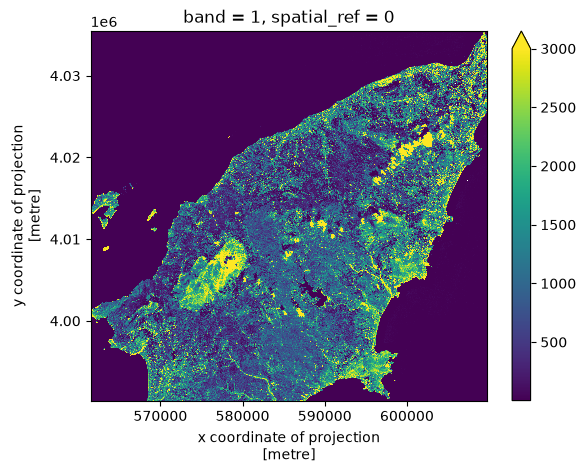

In [6]:
red_clip.plot(robust=True)

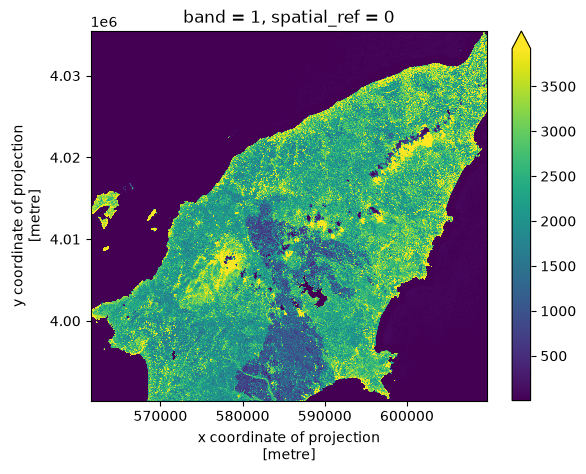

In [7]:
nir_clip.plot(robust=True)

## 2. Raster math: NDVI

In [8]:
print(red_clip.shape, nir_clip.shape)

(1, 4523, 4828) (1, 4523, 4828)


In [9]:
ndvi = (nir_clip - red_clip) / (nir_clip + red_clip)
print(ndvi)

<xarray.DataArray (band: 1, y: 4523, x: 4828)> Size: 87MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]],
      shape=(1, 4523, 4828), dtype=float32)
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 36kB 4.035e+06 4.035e+06 ... 3.99e+06 3.99e+06
  * x            (x) float64 39kB 5.615e+05 5.615e+05 ... 6.098e+05 6.098e+05
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  AVERAGE
    AREA_OR_POINT:       Area
    scale_factor:        1.0
    add_offset:          0.0


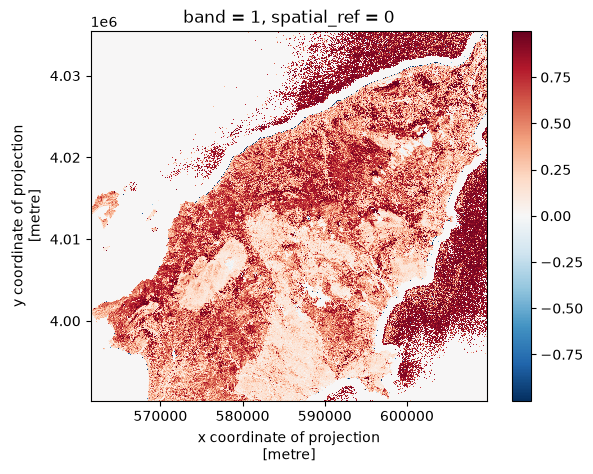

In [10]:
ndvi.plot()

(array([2.576200e+04, 4.145000e+03, 4.371000e+03, 9.883000e+03,
        7.936025e+06, 2.940162e+06, 3.273823e+06, 2.356497e+06,
        2.250095e+06, 3.035424e+06]),
 array([-9.98985291e-01, -7.99112439e-01, -5.99239588e-01, -3.99366677e-01,
        -1.99493825e-01,  3.79025936e-04,  2.00251937e-01,  4.00124788e-01,
         5.99997640e-01,  7.99870491e-01,  9.99743342e-01]),
 <BarContainer object of 10 artists>)

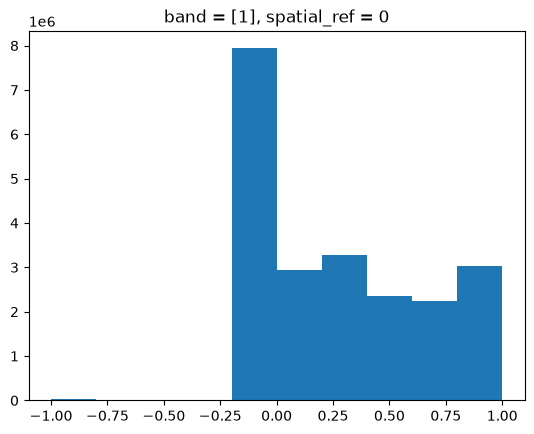

In [11]:
ndvi.plot.hist()

## 3. Exercise: NDWI and a custom index to detect burned areas

In [12]:
def get_band_and_clip(band_path, bbox):
    band = rioxarray.open_rasterio(band_path, masked=True)
    return band.rio.clip_box(*bbox)

In [13]:
data_path = "../data/sentinel2"
green_clip = get_band_and_clip(f"{data_path}/green.tif", bbox)
swir16_clip = get_band_and_clip(f"{data_path}/swir16.tif", bbox)
swir22_clip = get_band_and_clip(f"{data_path}/swir22.tif", bbox)

In [14]:
ndwi = (green_clip - nir_clip) / (green_clip + nir_clip)
index = (swir16_clip - swir22_clip) / (swir16_clip + swir22_clip)

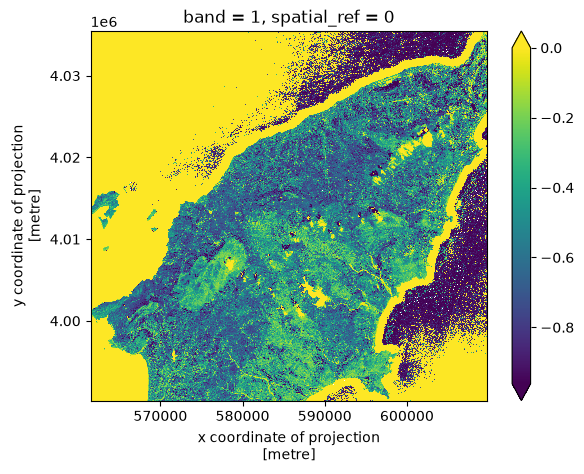

In [15]:
ndwi.plot(robust=True)

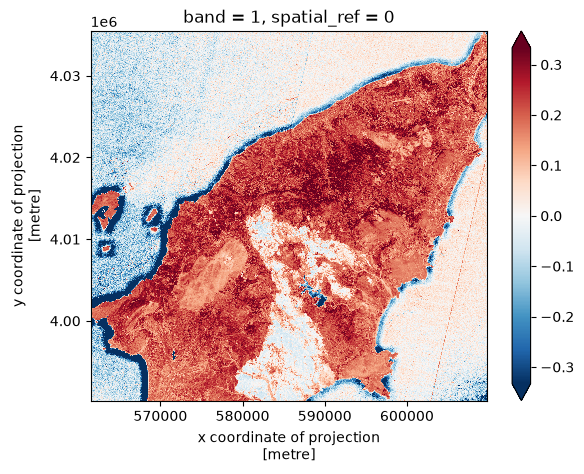

In [16]:
index.plot(robust=True)

In [17]:
ndvi.rio.resolution(), ndwi.rio.resolution(), index.rio.resolution()

((10.0, -10.0), (10.0, -10.0), (20.0, -20.0))

In [18]:
index_match = index.rio.reproject_match(ndvi)
swir16_match = swir16_clip.rio.reproject_match(ndvi)

In [19]:
blue_clip = get_band_and_clip(f"{data_path}/blue.tif", bbox)

In [20]:
burned = (
    (ndvi <= 0.3) &
    (ndwi <= 0.1) &
    ((index_match + nir_clip / 10_000) <= 0.1) &
    ((blue_clip / 10_000) <= 0.1) &
    ((swir16_match / 10_000) >= 0.1)
)

In [21]:
burned = burned.squeeze()

In [22]:
visual = rioxarray.open_rasterio(f"{data_path}/visual.tif")
visual_clip = visual.rio.clip_box(*bbox)

In [23]:
visual_clip[0] = visual_clip[0].where(~burned, 255)
visual_clip[1:3] = visual_clip[1:3].where(~burned, 0)

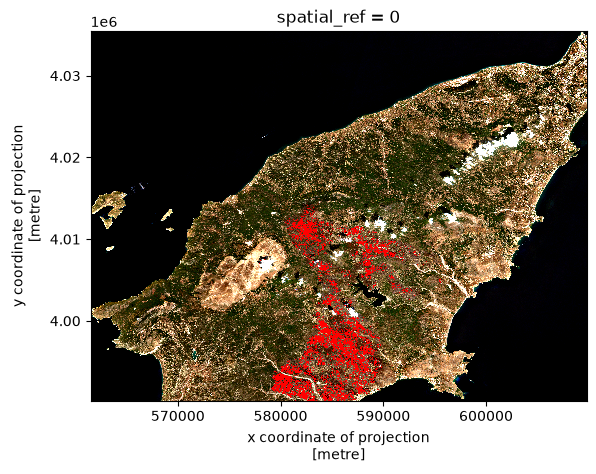

In [24]:
visual_clip.plot.imshow()

In [25]:
# `burned` is a boolean mask that inherited a NaN nodata value from the
# masked source bands, which rioxarray can't cast to int8 on save. Cast to
# int8 and drop the inherited nodata before writing.
burned_int8 = burned.astype("int8")
burned_int8.attrs.pop("_FillValue", None)
burned_int8.rio.write_nodata(None, inplace=True)
burned_int8.rio.to_raster("../outputs/burned.tif")